## **Shruti Rajput- RBA58**


##Problem statement - To Identify Whether the transaction is Fraduelent or not?

1. Data cleaning and removing unneccessary columns.
2.  Encoding data
3. identify outliers and checking multicollinearity.
4. Exploratory data analysis
5. train test split
6. dropping column where p value is more then 0.05, and refitting the model

In [48]:
import pandas as pd


In [49]:
df = pd.read_excel('/content/Fraud_Detection_Dataset.xlsx', sheet_name='Transactions', header=0)

In [50]:
df.head()

,Transaction_ID,Transaction_Date,Transaction_Time,Customer_ID,Customer_Name,Customer_Age,Account_Tenure_Months,Transaction_Amount_USD,Merchant_Category,Merchant_Name,...,Distance_From_Home_KM,Distance_From_Last_Transaction_KM,Time_Since_Last_Transaction_Hrs,Num_Transactions_Last_24h,Avg_Transaction_Amount_30d_USD,IP_Risk_Score,Is_Weekend,Is_Night_Transaction,Previous_Fraud_Flag,Is_Fraud
0,TXN200000,2025-01-15,06:48:02,CUST100030,Aditya Patel,41,2,199.98,Home Improvement,HomeFix,...,54.2,21.5,15.50,2,273.49,0.273,0,0,0,0
1,TXN200001,2025-04-06,11:04:13,CUST101156,Rohan Kumar,42,11,66.32,Clothing,FashionPoint,...,37.3,23.7,5.42,2,95.22,0.168,1,0,0,0
2,TXN200002,2025-01-21,13:21:11,CUST100068,Ava Sharma,38,1,91.12,Digital Goods,DigiMedia,...,39.7,8.5,3.03,1,40.02,0.586,0,0,0,0
3,TXN200003,2025-11-15,19:07:56,CUST100165,Wei Sharma,43,37,54.56,Entertainment,StreamPlus,...,35.1,4.5,26.32,0,42.80,0.101,1,0,0,0
4,TXN200004,2025-04-09,10:35:46,CUST100063,James Singh,42,43,516.69,Money Transfer,SendFast,...,32.9,9.1,16.08,1,247.95,0.268,0,0,0,0


In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 27 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Transaction_ID                     5000 non-null   object 
 1   Transaction_Date                   5000 non-null   object 
 2   Transaction_Time                   5000 non-null   object 
 3   Customer_ID                        5000 non-null   object 
 4   Customer_Name                      5000 non-null   object 
 5   Customer_Age                       5000 non-null   int64  
 6   Account_Tenure_Months              5000 non-null   int64  
 7   Transaction_Amount_USD             5000 non-null   float64
 8   Merchant_Category                  5000 non-null   object 
 9   Merchant_Name                      5000 non-null   object 
 10  Transaction_Type                   5000 non-null   object 
 11  Device_Type                        5000 non-null   objec

In [52]:
df.isnull().sum()

,0
Transaction_ID,0
Transaction_Date,0
Transaction_Time,0
Customer_ID,0
Customer_Name,0
Customer_Age,0
Account_Tenure_Months,0
Transaction_Amount_USD,0
Merchant_Category,0
Merchant_Name,0


# Removing Unnecessary Columns

In [53]:
df = df.drop(columns=[
    'Transaction_ID',
    'Customer_ID',
    'Customer_Name',
    'Merchant_Name'
], errors='ignore')

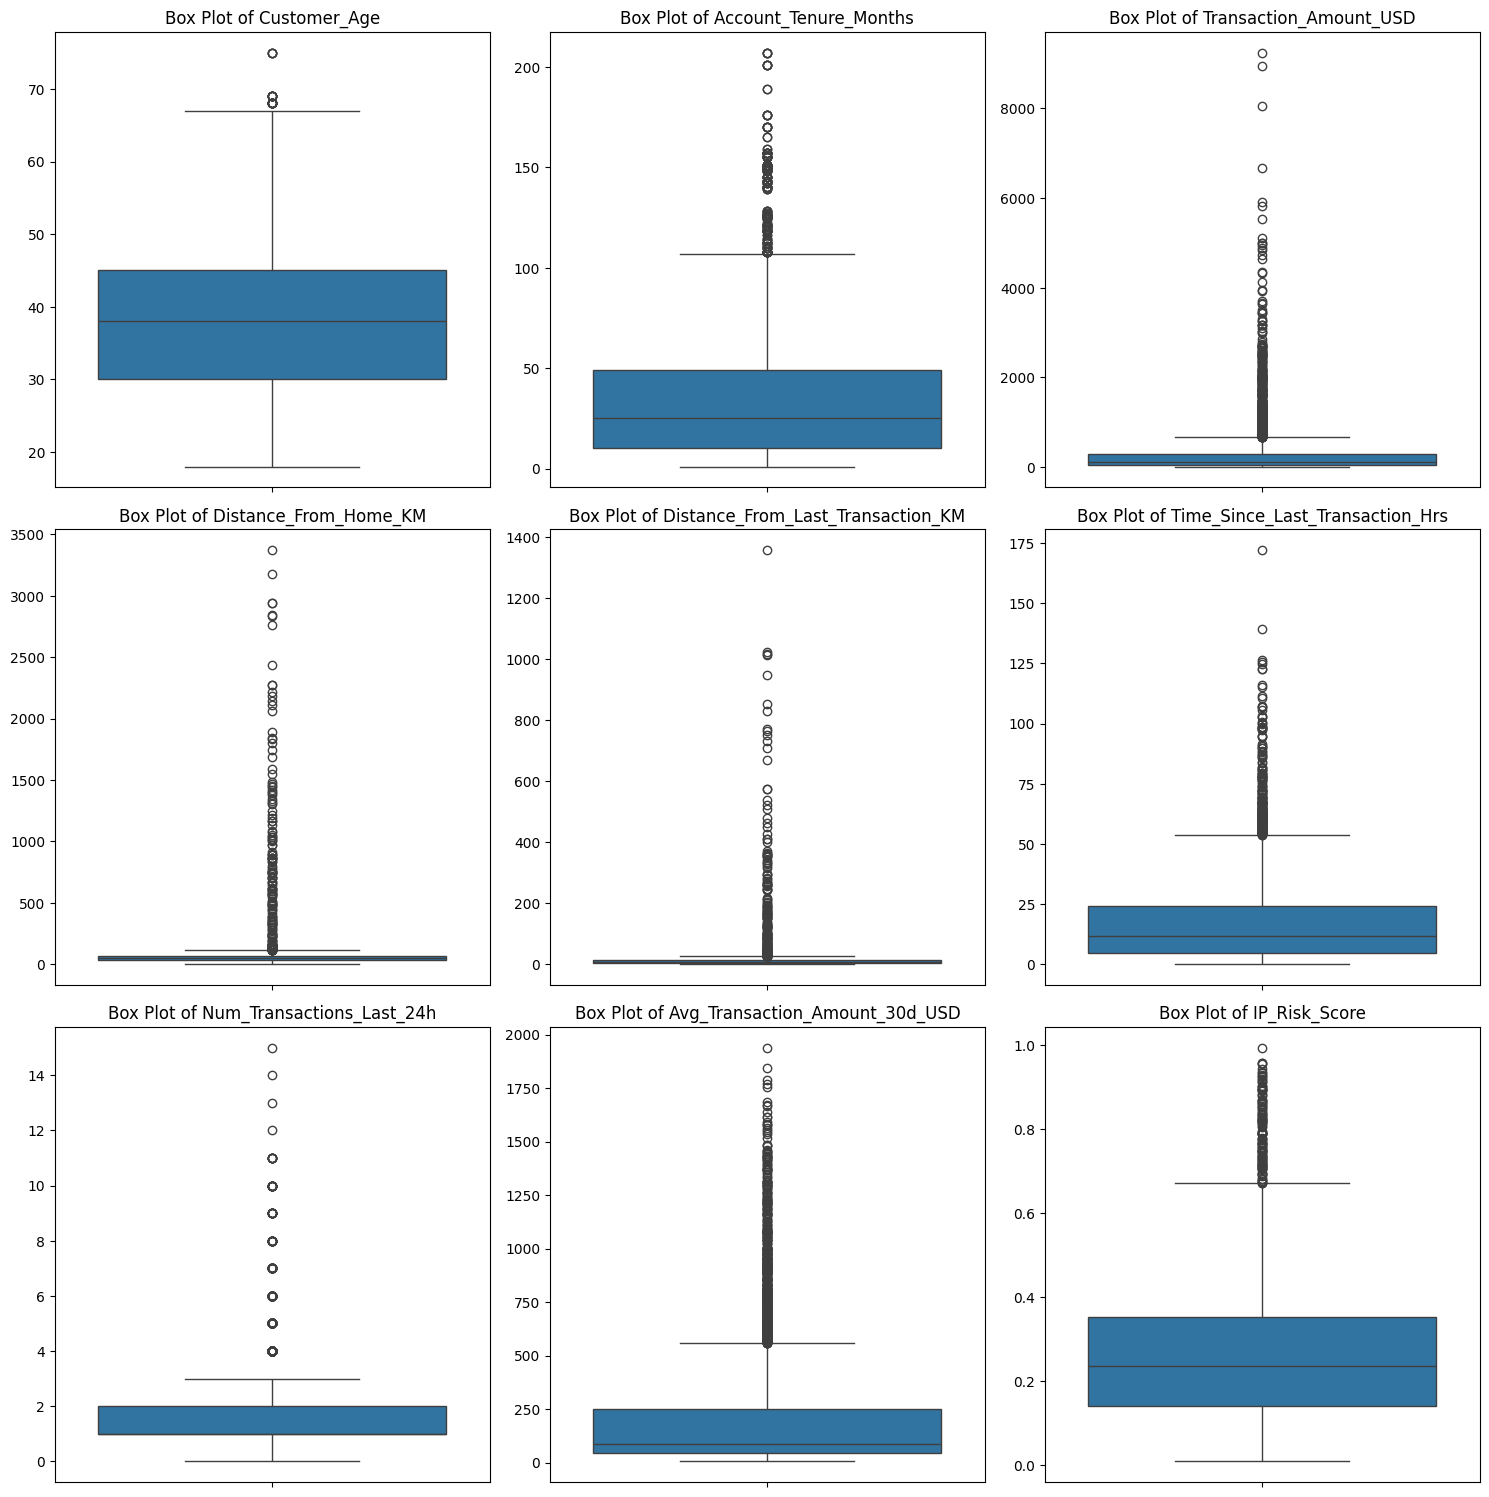

In [54]:
# Identify numerical columns first
numerical_cols = df.select_dtypes(include=['number']).columns

# Define columns that are considered binary/categorical even if numeric
excluded_binary_cols = ['Is_Weekend', 'Is_Night_Transaction', 'Previous_Fraud_Flag', 'Is_Fraud']

# Filter to get continuous numerical columns by excluding the binary ones
continuous_cols = [col for col in numerical_cols if col not in excluded_binary_cols]

if not continuous_cols:
    print("No continuous numerical columns found based on the filtering criteria.")
else:
    # Create box plots for each continuous numerical column to visualize outliers
    plt.figure(figsize=(15, 5 * (len(continuous_cols) // 3 + 1)))
    for i, col in enumerate(continuous_cols):
        plt.subplot(len(continuous_cols) // 3 + 1, 3, i + 1)
        sns.boxplot(y=df[col])
        plt.title(f'Box Plot of {col}')
        plt.ylabel('')
    plt.tight_layout()
    plt.show()

# correlation

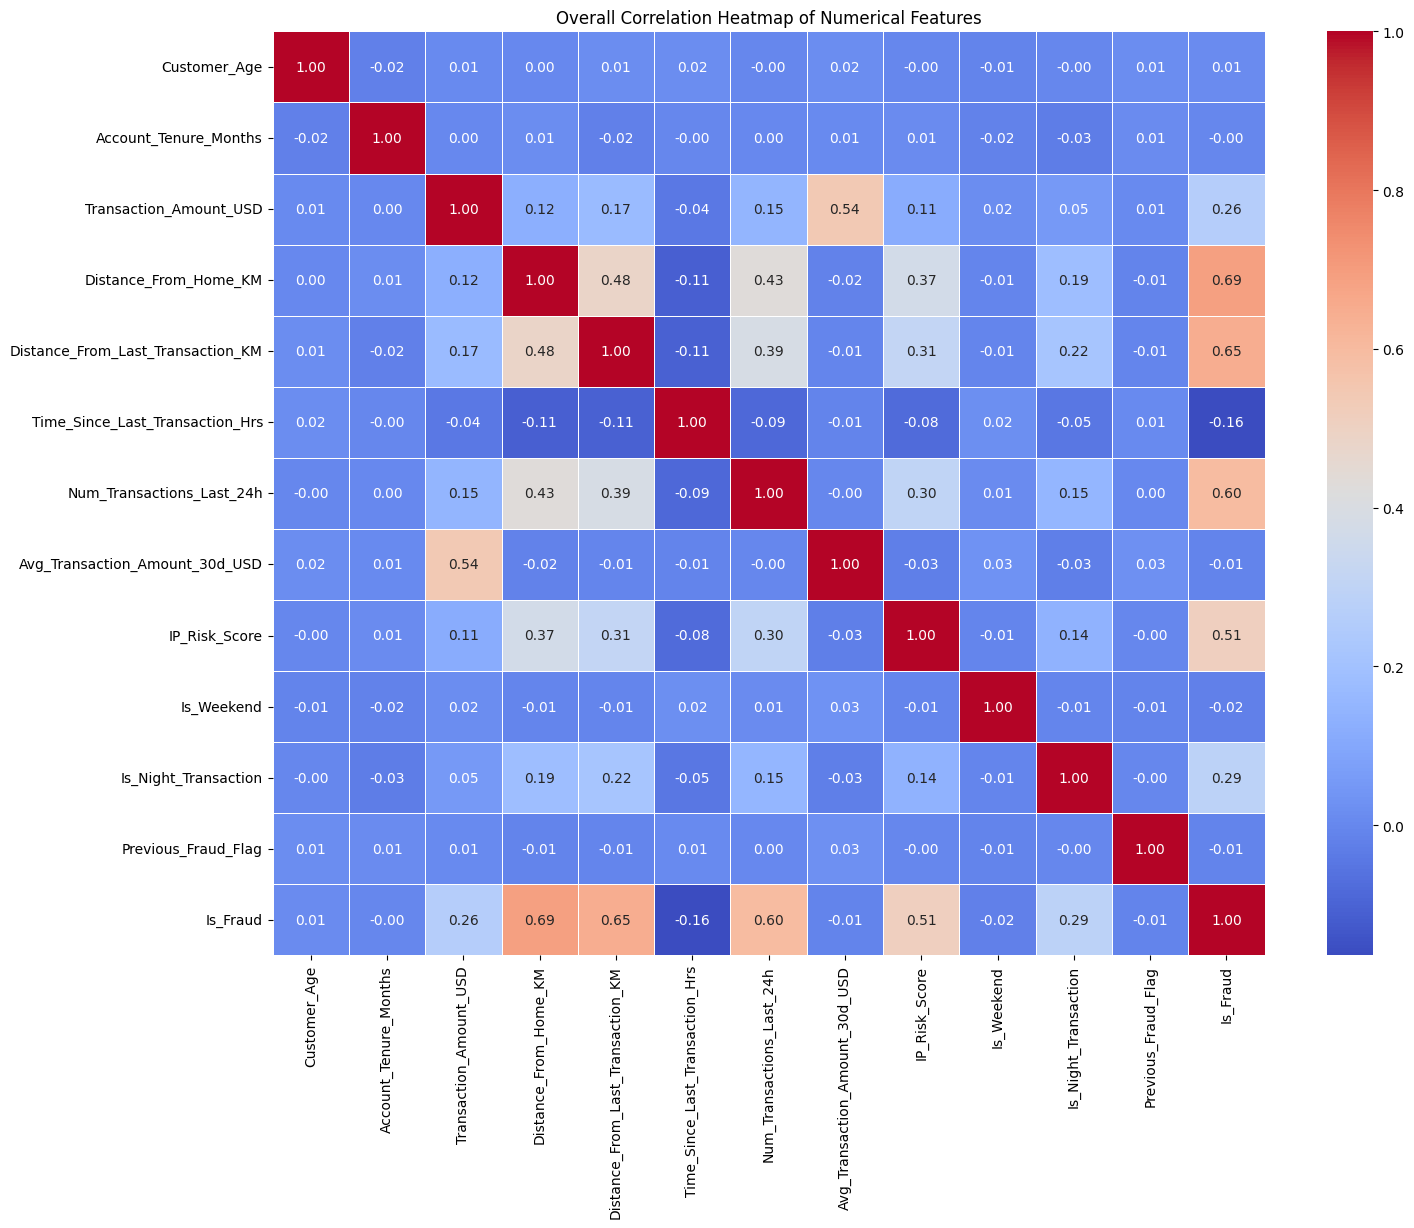

In [55]:
# Select only numerical columns for the overall correlation heatmap
numerical_df = df.select_dtypes(include=['float64', 'int64'])

# Calculate the overall correlation matrix
overall_correlation_matrix = numerical_df.corr()

plt.figure(figsize=(16, 12))
sns.heatmap(overall_correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Overall Correlation Heatmap of Numerical Features')
plt.show()

### One-Hot Encoding Categorical Features

One-hot encoding converts categorical variables into a format that can be provided to machine learning algorithms. Each category value is converted into a new column, and a 1 or 0 value is placed in the column to denote its presence or absence. This prevents the model from assuming any ordinal relationship between categories.

For `Card_Present`, since it's already in a binary (0/1) format, we will ensure its data type is appropriate (integer) rather than applying one-hot encoding.

In [56]:
import pandas as pd

# Columns to one-hot encode
categorical_cols_to_encode = [
    'Merchant_Category',
    'Transaction_Type',
    'Device_Type'
]

# Filter out columns that are no longer in the DataFrame
# This handles cases where the cell might be re-executed after encoding
existing_categorical_cols = [col for col in categorical_cols_to_encode if col in df.columns]

if existing_categorical_cols:
    print(f"Applying one-hot encoding to: {existing_categorical_cols}")
    df = pd.get_dummies(df, columns=existing_categorical_cols, drop_first=True)
else:
    print("Categorical columns for one-hot encoding already processed or not found.")


# Convert 'Card_Present' from 'Yes'/'No' to 1/0 and then to int
# Check if 'Card_Present' column exists and is of 'object' type before mapping
if 'Card_Present' in df.columns and df['Card_Present'].dtype == 'object':
    df['Card_Present'] = df['Card_Present'].map({'Yes': 1, 'No': 0}).astype(int)
    print(" 'Card_Present' column converted to 0/1 integers.")
elif 'Card_Present' in df.columns:
    print("'Card_Present' column is not of object type or already processed.")
else:
    print("'Card_Present' column not found.")


print("\nDataFrame after one-hot encoding and 'Card_Present' conversion:")
display(df.head())
print("\nUpdated DataFrame info:")
df.info()

Applying one-hot encoding to: ['Merchant_Category', 'Transaction_Type', 'Device_Type']
 'Card_Present' column converted to 0/1 integers.

DataFrame after one-hot encoding and 'Card_Present' conversion:


,Transaction_Date,Transaction_Time,Customer_Age,Account_Tenure_Months,Transaction_Amount_USD,Card_Present,Transaction_City,Transaction_Country,Home_City,Home_Country,...,Merchant_Category_Online Retail,Merchant_Category_Restaurant,Merchant_Category_Travel,Merchant_Category_Utilities,Transaction_Type_Contactless,Transaction_Type_Online,Transaction_Type_POS,Device_Type_Mobile App,Device_Type_POS Terminal,Device_Type_Web Browser
0,2025-01-15,06:48:02,41,2,199.98,1,Chennai,India,Bengaluru,India,...,False,False,False,False,False,False,False,False,False,True
1,2025-04-06,11:04:13,42,11,66.32,0,Delhi,India,Lagos,Nigeria,...,False,False,False,False,False,False,False,False,False,True
2,2025-01-21,13:21:11,38,1,91.12,1,New York,USA,Mumbai,India,...,False,False,False,False,False,True,False,True,False,False
3,2025-11-15,19:07:56,43,37,54.56,1,Delhi,India,Dubai,UAE,...,False,False,False,False,False,True,False,True,False,False
4,2025-04-09,10:35:46,42,43,516.69,0,New York,USA,Mumbai,India,...,False,False,False,False,False,True,False,False,False,False



Updated DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 39 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Transaction_Date                    5000 non-null   object 
 1   Transaction_Time                    5000 non-null   object 
 2   Customer_Age                        5000 non-null   int64  
 3   Account_Tenure_Months               5000 non-null   int64  
 4   Transaction_Amount_USD              5000 non-null   float64
 5   Card_Present                        5000 non-null   int64  
 6   Transaction_City                    5000 non-null   object 
 7   Transaction_Country                 5000 non-null   object 
 8   Home_City                           5000 non-null   object 
 9   Home_Country                        5000 non-null   object 
 10  Distance_From_Home_KM               5000 non-null   float64
 11  Distance_From_Last

In [57]:
print("Updated DataFrame info:")
df.info()

Updated DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 39 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Transaction_Date                    5000 non-null   object 
 1   Transaction_Time                    5000 non-null   object 
 2   Customer_Age                        5000 non-null   int64  
 3   Account_Tenure_Months               5000 non-null   int64  
 4   Transaction_Amount_USD              5000 non-null   float64
 5   Card_Present                        5000 non-null   int64  
 6   Transaction_City                    5000 non-null   object 
 7   Transaction_Country                 5000 non-null   object 
 8   Home_City                           5000 non-null   object 
 9   Home_Country                        5000 non-null   object 
 10  Distance_From_Home_KM               5000 non-null   float64
 11  Distance_From_Last_

In [58]:
# Convert 'Transaction_Date' to datetime and extract features
df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date'])
df['Year'] = df['Transaction_Date'].dt.year
df['Month'] = df['Transaction_Date'].dt.month
df['Day'] = df['Transaction_Date'].dt.day
df['Weekday'] = df['Transaction_Date'].dt.dayofweek

print("Extracted Year, Month, Day, and Weekday from 'Transaction_Date'.")

Extracted Year, Month, Day, and Weekday from 'Transaction_Date'.


In [59]:
# Drop the original 'Transaction_Date' column
df.drop('Transaction_Date', axis=1, inplace=True)
print("Dropped original 'Transaction_Date' column.")

Dropped original 'Transaction_Date' column.


In [60]:
# Convert 'Transaction_Time' to datetime and extract 'Hour'
df['Transaction_Time'] = pd.to_datetime(df['Transaction_Time'], format='%H:%M:%S')
df['Hour'] = df['Transaction_Time'].dt.hour
print("Extracted Hour from 'Transaction_Time'.")

Extracted Hour from 'Transaction_Time'.


In [61]:
# Drop the original 'Transaction_Time' column
df.drop('Transaction_Time', axis=1, inplace=True)
print("Dropped original 'Transaction_Time' column.")

Dropped original 'Transaction_Time' column.


In [62]:
print("\nDataFrame after date and time feature engineering:")
display(df.head())
print("\nUpdated DataFrame info:")
df.info()


DataFrame after date and time feature engineering:


,Customer_Age,Account_Tenure_Months,Transaction_Amount_USD,Card_Present,Transaction_City,Transaction_Country,Home_City,Home_Country,Distance_From_Home_KM,Distance_From_Last_Transaction_KM,...,Transaction_Type_Online,Transaction_Type_POS,Device_Type_Mobile App,Device_Type_POS Terminal,Device_Type_Web Browser,Year,Month,Day,Weekday,Hour
0,41,2,199.98,1,Chennai,India,Bengaluru,India,54.2,21.5,...,False,False,False,False,True,2025,1,15,2,6
1,42,11,66.32,0,Delhi,India,Lagos,Nigeria,37.3,23.7,...,False,False,False,False,True,2025,4,6,6,11
2,38,1,91.12,1,New York,USA,Mumbai,India,39.7,8.5,...,True,False,True,False,False,2025,1,21,1,13
3,43,37,54.56,1,Delhi,India,Dubai,UAE,35.1,4.5,...,True,False,True,False,False,2025,11,15,5,19
4,42,43,516.69,0,New York,USA,Mumbai,India,32.9,9.1,...,True,False,False,False,False,2025,4,9,2,10



Updated DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 42 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Customer_Age                        5000 non-null   int64  
 1   Account_Tenure_Months               5000 non-null   int64  
 2   Transaction_Amount_USD              5000 non-null   float64
 3   Card_Present                        5000 non-null   int64  
 4   Transaction_City                    5000 non-null   object 
 5   Transaction_Country                 5000 non-null   object 
 6   Home_City                           5000 non-null   object 
 7   Home_Country                        5000 non-null   object 
 8   Distance_From_Home_KM               5000 non-null   float64
 9   Distance_From_Last_Transaction_KM   5000 non-null   float64
 10  Time_Since_Last_Transaction_Hrs     5000 non-null   float64
 11  Num_Transactions_L

In [63]:
# Drop the specified object type columns
df.drop(columns=['Transaction_City', 'Transaction_Country', 'Home_City', 'Home_Country'], inplace=True)

print("Dropped 'Transaction_City', 'Transaction_Country', 'Home_City', and 'Home_Country' columns.")

Dropped 'Transaction_City', 'Transaction_Country', 'Home_City', and 'Home_Country' columns.


In [64]:
print("\nDataFrame after dropping specified columns:")
display(df.head())
print("\nUpdated DataFrame info:")
df.info()


DataFrame after dropping specified columns:


,Customer_Age,Account_Tenure_Months,Transaction_Amount_USD,Card_Present,Distance_From_Home_KM,Distance_From_Last_Transaction_KM,Time_Since_Last_Transaction_Hrs,Num_Transactions_Last_24h,Avg_Transaction_Amount_30d_USD,IP_Risk_Score,...,Transaction_Type_Online,Transaction_Type_POS,Device_Type_Mobile App,Device_Type_POS Terminal,Device_Type_Web Browser,Year,Month,Day,Weekday,Hour
0,41,2,199.98,1,54.2,21.5,15.50,2,273.49,0.273,...,False,False,False,False,True,2025,1,15,2,6
1,42,11,66.32,0,37.3,23.7,5.42,2,95.22,0.168,...,False,False,False,False,True,2025,4,6,6,11
2,38,1,91.12,1,39.7,8.5,3.03,1,40.02,0.586,...,True,False,True,False,False,2025,1,21,1,13
3,43,37,54.56,1,35.1,4.5,26.32,0,42.80,0.101,...,True,False,True,False,False,2025,11,15,5,19
4,42,43,516.69,0,32.9,9.1,16.08,1,247.95,0.268,...,True,False,False,False,False,2025,4,9,2,10



Updated DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 38 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Customer_Age                        5000 non-null   int64  
 1   Account_Tenure_Months               5000 non-null   int64  
 2   Transaction_Amount_USD              5000 non-null   float64
 3   Card_Present                        5000 non-null   int64  
 4   Distance_From_Home_KM               5000 non-null   float64
 5   Distance_From_Last_Transaction_KM   5000 non-null   float64
 6   Time_Since_Last_Transaction_Hrs     5000 non-null   float64
 7   Num_Transactions_Last_24h           5000 non-null   int64  
 8   Avg_Transaction_Amount_30d_USD      5000 non-null   float64
 9   IP_Risk_Score                       5000 non-null   float64
 10  Is_Weekend                          5000 non-null   int64  
 11  Is_Night_Transacti

## Exploratory Data Analysis (EDA)

Let's begin with the distribution of our target variable, `Is_Fraud`, to understand the balance between fraudulent and non-fraudulent transactions.

/tmp/ipykernel_2515/760642340.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Is_Fraud', data=df, palette='viridis')


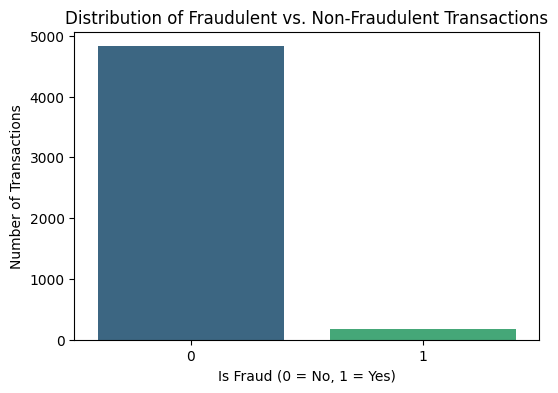


Counts of Is_Fraud:
 Is_Fraud
0    4825
1     175
Name: count, dtype: int64

Percentages of Is_Fraud:
 Is_Fraud
0    96.5
1     3.5
Name: proportion, dtype: float64


In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of the target variable 'Is_Fraud'
plt.figure(figsize=(6, 4))
sns.countplot(x='Is_Fraud', data=df, palette='viridis')
plt.title('Distribution of Fraudulent vs. Non-Fraudulent Transactions')
plt.xlabel('Is Fraud (0 = No, 1 = Yes)')
plt.ylabel('Number of Transactions')
plt.show()

# Print the count and percentage
fraud_counts = df['Is_Fraud'].value_counts()
fraud_percentages = df['Is_Fraud'].value_counts(normalize=True) * 100
print("\nCounts of Is_Fraud:\n", fraud_counts)
print("\nPercentages of Is_Fraud:\n", fraud_percentages)

### Relationship between Key Numerical Features and `Is_Fraud`

Based on our previous group-by analysis, `Transaction_Amount_USD`, `Distance_From_Home_KM`, and `IP_Risk_Score` showed significant differences. Let's visualize these differences using box plots.

/tmp/ipykernel_2515/3940978654.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Is_Fraud', y=feature, data=df, palette='coolwarm')
/tmp/ipykernel_2515/3940978654.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Is_Fraud', y=feature, data=df, palette='coolwarm')
/tmp/ipykernel_2515/3940978654.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Is_Fraud', y=feature, data=df, palette='coolwarm')


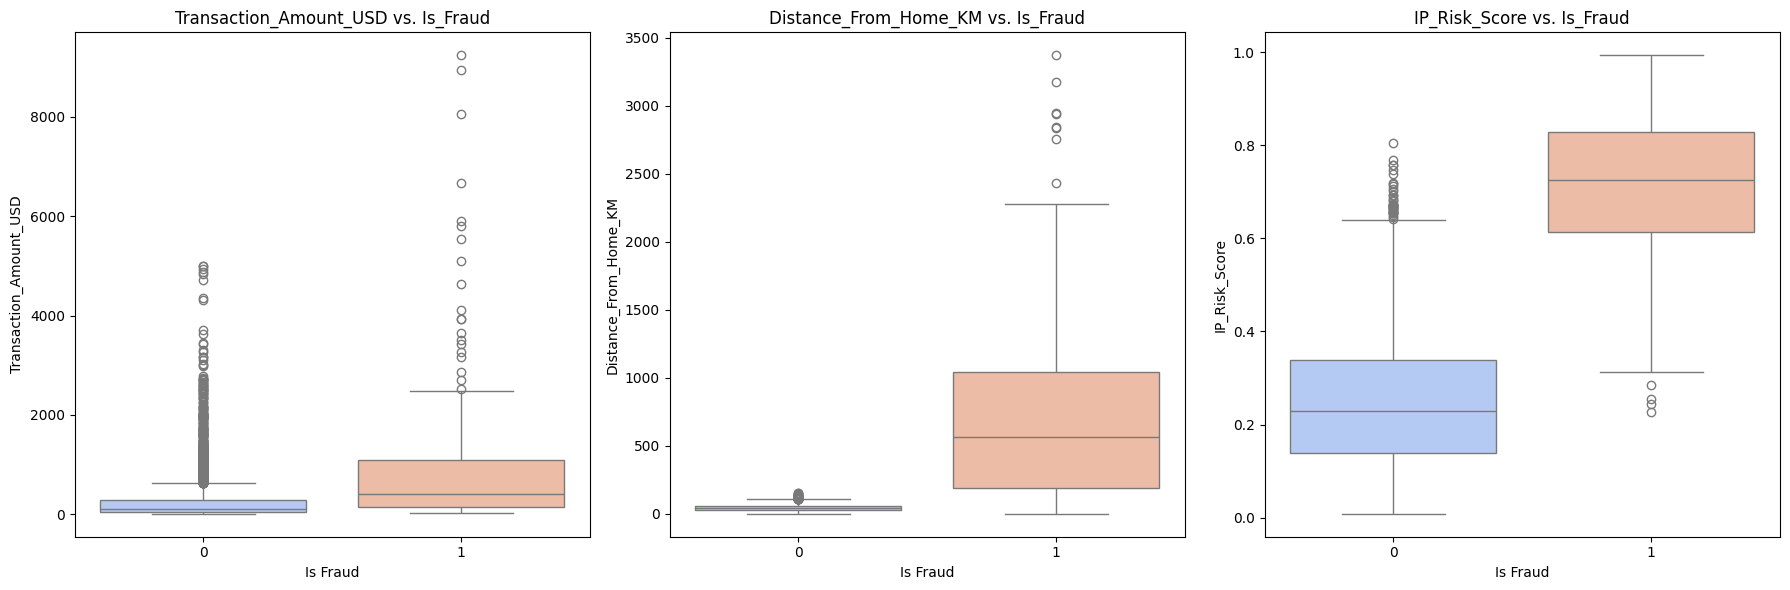

In [66]:
# Visualize key numerical features against 'Is_Fraud'
numerical_features_to_plot = ['Transaction_Amount_USD', 'Distance_From_Home_KM', 'IP_Risk_Score']

plt.figure(figsize=(18, 6))
for i, feature in enumerate(numerical_features_to_plot):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(x='Is_Fraud', y=feature, data=df, palette='coolwarm')
    plt.title(f'{feature} vs. Is_Fraud')
    plt.xlabel('Is Fraud')
    plt.ylabel(feature)
plt.tight_layout()
plt.show()

### Relationship between Time-Based Features and `Is_Fraud`

Let's also look at how the newly engineered 'Hour' and 'Weekday' features relate to fraud.

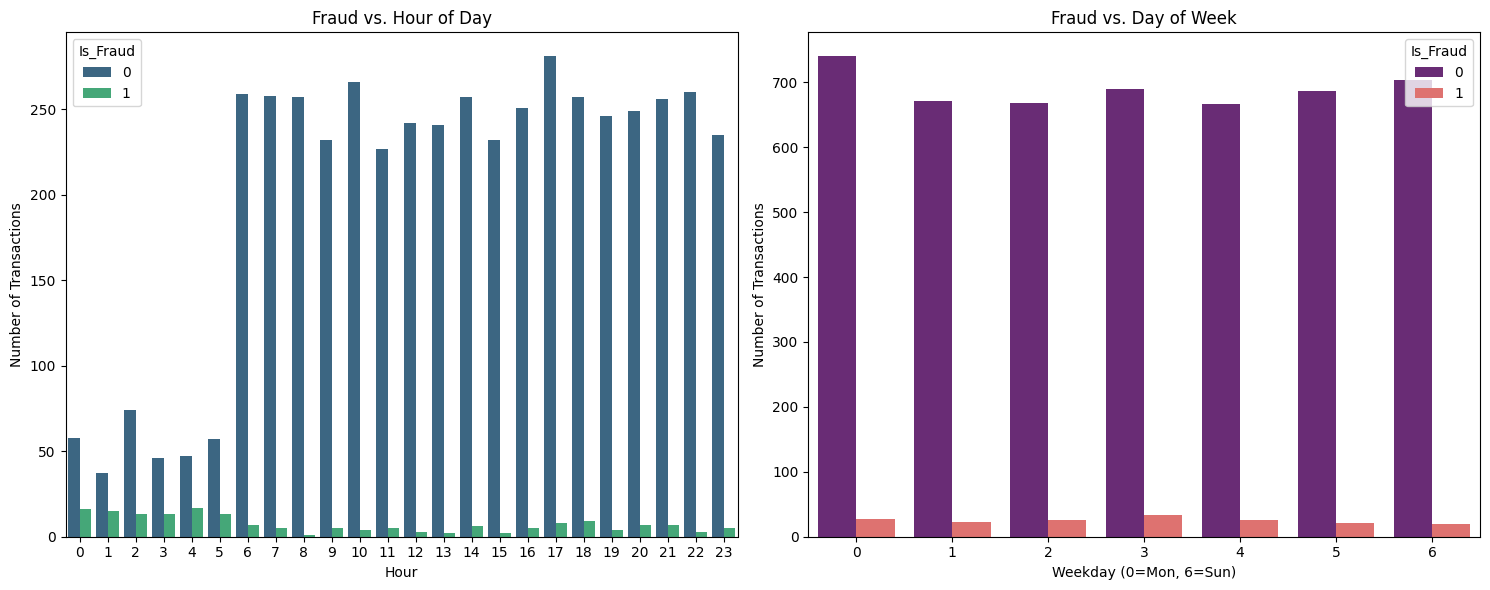

In [67]:
# Visualize 'Hour' and 'Weekday' against 'Is_Fraud'
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.countplot(x='Hour', hue='Is_Fraud', data=df, palette='viridis')
plt.title('Fraud vs. Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Number of Transactions')

plt.subplot(1, 2, 2)
sns.countplot(x='Weekday', hue='Is_Fraud', data=df, palette='magma')
plt.title('Fraud vs. Day of Week')
plt.xlabel('Weekday (0=Mon, 6=Sun)')
plt.ylabel('Number of Transactions')

plt.tight_layout()
plt.show()

### Hypothesis Testing: T-test for 'Is_Fraud' vs. Numerical Features

We will perform independent samples t-tests to compare the means of several numerical features between the two groups defined by the 'Is_Fraud' column (fraudulent vs. non-fraudulent transactions). The null hypothesis ($H_0$) is that there is no significant difference in the mean of the numerical feature between the two groups.

In [68]:
from scipy import stats

# Define the numerical columns to test against 'Is_Fraud'
features_to_test = ['Customer_Age', 'Account_Tenure_Months', 'Transaction_Amount_USD', 'IP_Risk_Score']

# Separate data into fraudulent and non-fraudulent groups
df_fraud = df[df['Is_Fraud'] == 1]
df_non_fraud = df[df['Is_Fraud'] == 0]

print("--- T-test Results ---")
for feature in features_to_test:
    print(f"\nComparing '{feature}' for Fraud vs. Non-Fraud:")

    # Perform independent samples t-test
    t_statistic, p_value = stats.ttest_ind(df_fraud[feature], df_non_fraud[feature], equal_var=False) # Welch's t-test as variances might not be equal

    print(f"  T-statistic: {t_statistic:.3f}")
    print(f"  P-value: {p_value:.3f}")

    # Interpret the results
    alpha = 0.05
    if p_value < alpha:
        print(f"  Conclusion: Reject the null hypothesis. There is a statistically significant difference in the mean '{feature}' between fraudulent and non-fraudulent transactions.")
    else:
        print(f"  Conclusion: Fail to reject the null hypothesis. There is no statistically significant difference in the mean '{feature}' between fraudulent and non-fraudulent transactions.")


--- T-test Results ---

Comparing 'Customer_Age' for Fraud vs. Non-Fraud:
  T-statistic: 0.663
  P-value: 0.508
  Conclusion: Fail to reject the null hypothesis. There is no statistically significant difference in the mean 'Customer_Age' between fraudulent and non-fraudulent transactions.

Comparing 'Account_Tenure_Months' for Fraud vs. Non-Fraud:
  T-statistic: -0.246
  P-value: 0.806
  Conclusion: Fail to reject the null hypothesis. There is no statistically significant difference in the mean 'Account_Tenure_Months' between fraudulent and non-fraudulent transactions.

Comparing 'Transaction_Amount_USD' for Fraud vs. Non-Fraud:
  T-statistic: 6.390
  P-value: 0.000
  Conclusion: Reject the null hypothesis. There is a statistically significant difference in the mean 'Transaction_Amount_USD' between fraudulent and non-fraudulent transactions.

Comparing 'IP_Risk_Score' for Fraud vs. Non-Fraud:
  T-statistic: 36.588
  P-value: 0.000
  Conclusion: Reject the null hypothesis. There is a st

We Can infer Customer age does not vary with fraudlent transactions . As the p Value of account tenure is greater than 0.05 we fail to reject null hypothesis that there is some significant difference in account tenure in fraud and non-fraud transactions.

Also There is significant difference in transaction amount , ip risk score in fraud and non fraud transactions.

## Train-Test Split

Before building a machine learning model, we need to split our data into features (X) and the target variable (y). Then, we'll divide these into training and testing sets to evaluate the model's performance on unseen data.

In [69]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
# Drop 'Is_Fraud' and other non-numeric/identifier columns
X = df.drop(columns=['Is_Fraud', 'Transaction_ID', 'Customer_ID', 'Customer_Name', 'Merchant_Name'], errors='ignore')
y = df['Is_Fraud']

# Perform train-test split
# Using a stratify argument to maintain the proportion of 'Is_Fraud' in both train and test sets
# This is important given the class imbalance identified in EDA.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

print("\nClass distribution in original data:")
print(y.value_counts(normalize=True))
print("\nClass distribution in y_train:")
print(y_train.value_counts(normalize=True))
print("\nClass distribution in y_test:")
print(y_test.value_counts(normalize=True))

Shape of X_train: (4000, 37)
Shape of X_test: (1000, 37)
Shape of y_train: (4000,)
Shape of y_test: (1000,)

Class distribution in original data:
Is_Fraud
0    0.965
1    0.035
Name: proportion, dtype: float64

Class distribution in y_train:
Is_Fraud
0    0.965
1    0.035
Name: proportion, dtype: float64

Class distribution in y_test:
Is_Fraud
0    0.965
1    0.035
Name: proportion, dtype: float64


## Logistic Regression with `statsmodels`



In [70]:
import statsmodels.api as sm

# Print dtypes to debug any remaining object columns
print("X dtypes before adding constant:")
print(X.dtypes)

# Convert boolean columns to integers
for col in X.select_dtypes(include='bool').columns:
    X[col] = X[col].astype(int)

print("\nX dtypes after converting bool to int:")
print(X.dtypes)

# Add a constant to the independent variables, which is required for statsmodels logistic regression
X_const = sm.add_constant(X)

# Create and fit the logistic regression model
logit_model = sm.Logit(y, X_const)
result = logit_model.fit()

# Display the model summary
display(result.summary())

X dtypes before adding constant:
Customer_Age                            int64
Account_Tenure_Months                   int64
Transaction_Amount_USD                float64
Card_Present                            int64
Distance_From_Home_KM                 float64
Distance_From_Last_Transaction_KM     float64
Time_Since_Last_Transaction_Hrs       float64
Num_Transactions_Last_24h               int64
Avg_Transaction_Amount_30d_USD        float64
IP_Risk_Score                         float64
Is_Weekend                              int64
Is_Night_Transaction                    int64
Previous_Fraud_Flag                     int64
Merchant_Category_Digital Goods          bool
Merchant_Category_Electronics            bool
Merchant_Category_Entertainment          bool
Merchant_Category_Gas Station            bool
Merchant_Category_Grocery                bool
Merchant_Category_Healthcare             bool
Merchant_Category_Home Improvement       bool
Merchant_Category_Jewelry                bool
M

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:               Is_Fraud   No. Observations:                 5000
Model:                          Logit   Df Residuals:                     4963
Method:                           MLE   Df Model:                           36
Date:                Thu, 16 Jul 2026   Pseudo R-squ.:                   1.000
Time:                        06:31:39   Log-Likelihood:            -1.7821e-05
converged:                      False   LL-Null:                       -758.57
Covariance Type:            nonrobust   LLR p-value:                9.439e-296
======================================================================================================
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Customer_Age                           0.0287    156.597      0.000      1.000    -306.896     306.953
Account_Tenure_Months                 -0.0275     51.010     -0.001      1.000    -100.006      99.951
Transaction_Amount_USD                 0.0104      3.247      0.003      0.997      -6.354       6.375
Card_Present                         -12.5675   4247.437     -0.003      0.998   -8337.391    8312.256
Distance_From_Home_KM                  0.0869     27.362      0.003      0.997     -53.541      53.714
Distance_From_Last_Transaction_KM      0.7453    194.593      0.004      0.997    -380.650     382.140
Time_Since_Last_Transaction_Hrs       -0.2046    113.546     -0.002      0.999    -222.752     222.342
Num_Transactions_Last_24h              5.7805   1464.650      0.004      0.997   -2864.881    2876.442
Avg_Transaction_Amount_30d_USD         0.0240     15.591      0.002      0.999     -30.533      30.581
IP_Risk_Score                         57.3375   1.89e+04      0.003      0.998   -3.69e+04     3.7e+04
Is_Weekend                             2.6329   6591.944      0.000      1.000   -1.29e+04    1.29e+04
Is_Night_Transaction                  27.0745   8611.757      0.003      0.997   -1.69e+04    1.69e+04
Previous_Fraud_Flag                   18.0039   1.11e+04      0.002      0.999   -2.18e+04    2.18e+04
Merchant_Category_Digital Goods        7.6035   1.59e+04      0.000      1.000   -3.12e+04    3.13e+04
Merchant_Category_Electronics         -9.4691    1.6e+04     -0.001      1.000   -3.13e+04    3.13e+04
Merchant_Category_Entertainment      -11.3665   9779.238     -0.001      0.999   -1.92e+04    1.92e+04
Merchant_Category_Gas Station         -5.7435   1.09e+04     -0.001      1.000   -2.14e+04    2.13e+04
Merchant_Category_Grocery             -9.6812   4.84e+04     -0.000      1.000   -9.48e+04    9.48e+04
Merchant_Category_Healthcare          10.4201   1.41e+04      0.001      0.999   -2.76e+04    2.76e+04
Merchant_Category_Home Improvement    12.3705   1.46e+04      0.001      0.999   -2.87e+04    2.87e+04
Merchant_Category_Jewelry            -27.4454   2.56e+04     -0.001      0.999   -5.02e+04    5.01e+04
Merchant_Category_Money Transfer      -2.6585    1.7e+05  -1.56e-05      1.000   -3.33e+05    3.33e+05
Merchant_Category_Online Retail        1.6211   2.33e+04   6.95e-05      1.000   -4.57e+04    4.57e+04
Merchant_Category_Restaurant          21.0946   1.74e+04      0.001      0.999   -3.41e+04    3.41e+04
Merchant_Category_Travel             -37.0719   1.73e+04     -0.002      0.998   -3.39e+04    3.38e+04
Merchant_Category_Utilities           12.1887   1.19e+04      0.001      0.999   -2.33e+04    2.33e+04
Transaction_Type_Contactless           0.2580   7424.875   3.47e-05      1.000   -1.46e+04    1.46e+04
Transaction_Type_Online                5.3033   4679.257      0.001      0.999   -9165.871    9176.478
Transaction_Type_POS                  12.8576   

In [71]:
import statsmodels.api as sm

# Re-add a constant to the independent variables for the initial model run
X_const = sm.add_constant(X)

# Create and fit the logistic regression model to get p-values
logit_model = sm.Logit(y, X_const)

# Trying a more robust optimization method 'bfgs' to handle convergence issues
# disp=False to suppress iteration output during this step
try:
    result = logit_model.fit(method='bfgs', disp=False)
except Exception as e:
    print(f"Initial model fitting with bfgs failed: {e}")
    # Fallback to default if bfgs fails, but likely to have previous issues
    result = logit_model.fit(disp=False)

# Get p-values and identify the feature to drop
p_values = result.pvalues

# Identify the feature with the highest p-value that is 1.000 (if any)
# Assuming 'Customer_Age' was already removed, let's find the *next* highest
# filtering out 'const' and NaN p-values if they appear due to separation
p_values_filtered = p_values[p_values.index != 'const'].dropna()

if not p_values_filtered.empty:
    max_p_value = p_values_filtered.max()
    if max_p_value == 1.000:
        column_to_drop = p_values_filtered[p_values_filtered == max_p_value].index[0]
        print(f"Column identified to drop due to p-value of 1.000: {column_to_drop}")
    elif max_p_value > 0.05:
        column_to_drop = p_values_filtered.idxmax()
        print(f"Column identified to drop due to highest p-value ({max_p_value:.3f}): {column_to_drop}")
    else:
        column_to_drop = None
        print("No column found with p-value of 1.000 or greater than 0.05. Model appears stable.")
else:
    column_to_drop = None
    print("No features with calculable p-values to consider dropping.")


if column_to_drop:
    # Drop the identified column from X
    X_reduced = X.drop(columns=[column_to_drop])

    # Re-add a constant to the independent variables for the re-fitted model
    X_reduced_const = sm.add_constant(X_reduced)

    # Create and re-fit the logistic regression model with the reduced set of features
    # Trying 'bfgs' method again for robustness
    try:
        logit_model_reduced = sm.Logit(y, X_reduced_const)
        result_reduced = logit_model_reduced.fit(method='bfgs')
        # Display the model summary for the re-fitted model
        display(result_reduced.summary())
    except Exception as e:
        print(f"Re-fitting model with reduced features and bfgs method failed: {e}")
        print("Trying default fit method as a fallback...")
        try:
            result_reduced = logit_model_reduced.fit()
            display(result_reduced.summary())
        except Exception as e_fallback:
            print(f"Fallback fitting also failed: {e_fallback}")
            print("The model is highly unstable. Consider feature scaling, regularization, or alternative models.")
else:
    print("No feature was dropped in this iteration as no high p-value feature was identified.")
    # If no column was dropped, we should show the summary of the previous 'result' if available and converged
    if 'result' in locals() and result.mle_retvals['converged']:
        print("Displaying summary of the model without further feature drops:")
        display(result.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: ove

Column identified to drop due to highest p-value (1.000): Previous_Fraud_Flag
         Current function value: 0.001583
         Iterations: 35
         Function evaluations: 48
         Gradient evaluations: 42


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:               Is_Fraud   No. Observations:                 5000
Model:                          Logit   Df Residuals:                     4964
Method:                           MLE   Df Model:                           35
Date:                Thu, 16 Jul 2026   Pseudo R-squ.:                  0.9896
Time:                        06:31:39   Log-Likelihood:                -7.9127
converged:                      False   LL-Null:                       -758.57
Covariance Type:            nonrobust   LLR p-value:                3.269e-293
======================================================================================================
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Customer_Age                          -0.0235      0.057     -0.410      0.682      -0.136       0.089
Account_Tenure_Months                 -0.0114      0.023     -0.493      0.622      -0.057       0.034
Transaction_Amount_USD                 0.0017      0.001      1.150      0.250      -0.001       0.005
Card_Present                          -0.3570      1.361     -0.262      0.793      -3.024       2.310
Distance_From_Home_KM                  0.0333      0.020      1.652      0.098      -0.006       0.073
Distance_From_Last_Transaction_KM      0.1567      0.048      3.237      0.001       0.062       0.252
Time_Since_Last_Transaction_Hrs       -0.1203      0.101     -1.188      0.235      -0.319       0.078
Num_Transactions_Last_24h              1.4530      0.436      3.336      0.001       0.599       2.307
Avg_Transaction_Amount_30d_USD        -0.0038      0.006     -0.653      0.514      -0.015       0.008
IP_Risk_Score                          0.2677      3.796      0.071      0.944      -7.173       7.708
Is_Weekend                            -0.0303      2.481     -0.012      0.990      -4.894       4.833
Is_Night_Transaction                   0.1500      2.531      0.059      0.953      -4.811       5.111
Merchant_Category_Digital Goods        0.0036      3.410      0.001      0.999      -6.681       6.688
Merchant_Category_Electronics          0.0104      4.363      0.002      0.998      -8.540       8.561
Merchant_Category_Entertainment        0.0017      3.352      0.001      1.000      -6.568       6.571
Merchant_Category_Gas Station          0.0479      4.483      0.011      0.991      -8.738       8.834
Merchant_Category_Grocery             -0.0321      3.755     -0.009      0.993      -7.391       7.327
Merchant_Category_Healthcare           0.0987      3.085      0.032      0.974      -5.948       6.145
Merchant_Category_Home Improvement    -0.0247      4.167     -0.006      0.995      -8.191       8.141
Merchant_Category_Jewelry             -0.0408      5.832     -0.007      0.994     -11.471      11.390
Merchant_Category_Money Transfer      -0.0267      3.740     -0.007      0.994      -7.356       7.303
Merchant_Category_Online Retail       -0.0222      3.678     -0.006      0.995      -7.232       7.187
Merchant_Category_Restaurant          -0.0119      3.470     -0.003      0.997      -6.813       6.789
Merchant_Category_Travel              -0.0345      4.405     -0.008      0.994      -8.667       8.598
Merchant_Category_Utilities           -0.0177      3.282     -0.005      0.996      -6.451       6.416
Transaction_Type_Contactless          -0.0102      1.960     -0.005      0.996      -3.852       3.831
Transaction_Type_Online               -0.0018      2.000     -0.001      0.999      -3.921       3.918
Transaction_Type_POS                   0.0794      1.977      0.040      0.968      -3.795       3.954
Device_Type_Mobile App                -0.0293   

In [72]:
import statsmodels.api as sm

# Define the list of features to drop cumulatively
# 'Previous_Fraud_Flag' was identified in the previous step.
# 'Merchant_Category_Entertainment' is requested to be dropped now.
dropped_features = ['Previous_Fraud_Flag', 'Merchant_Category_Entertainment']

print(f"Features to be removed from the model: {dropped_features}")

# Create the feature set by dropping the specified columns from the original X
# Using .copy() to ensure we don't modify the original X DataFrame accidentally
X_final_reduced = X.drop(columns=dropped_features, errors='ignore').copy()

print(f"Shape of X_final_reduced after dropping features: {X_final_reduced.shape}")

# Add a constant to the independent variables for statsmodels
X_final_reduced_const = sm.add_constant(X_final_reduced)

# Create and fit the logistic regression model with the new reduced set of features
print("Attempting to fit the Logit model with the further reduced features...")
try:
    logit_model_final = sm.Logit(y, X_final_reduced_const)
    # Trying 'bfgs' method again for robustness
    result_final = logit_model_final.fit(method='bfgs')
    # Display the model summary for the re-fitted model
    display(result_final.summary())
except Exception as e:
    print(f"Fitting model with further reduced features and bfgs method failed: {e}")
    print("Trying default fit method as a fallback...")
    try:
        result_final = logit_model_final.fit()
        display(result_final.summary())
    except Exception as e_fallback:
        print(f"Fallback fitting also failed: {e_fallback}")
        print("The model is highly unstable. Consider feature scaling, regularization, or alternative models.")

Features to be removed from the model: ['Previous_Fraud_Flag', 'Merchant_Category_Entertainment']
Shape of X_final_reduced after dropping features: (5000, 35)
Attempting to fit the Logit model with the further reduced features...
         Current function value: 0.001583
         Iterations: 35
         Function evaluations: 48
         Gradient evaluations: 42


/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))
/usr/local/lib/python3.12/dist-packages/scipy/optimize/_optimize.py:1330: OptimizeWarning: Maximum number of iterations has been exceeded.
  res = _minimize_bfgs(f, x0, args, fprime, callback=callback, **opts)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimi

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:               Is_Fraud   No. Observations:                 5000
Model:                          Logit   Df Residuals:                     4965
Method:                           MLE   Df Model:                           34
Date:                Thu, 16 Jul 2026   Pseudo R-squ.:                  0.9896
Time:                        06:31:39   Log-Likelihood:                -7.9127
converged:                      False   LL-Null:                       -758.57
Covariance Type:            nonrobust   LLR p-value:                4.880e-294
======================================================================================================
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Customer_Age                          -0.0235      0.057     -0.414      0.679      -0.135       0.088
Account_Tenure_Months                 -0.0114      0.023     -0.501      0.617      -0.056       0.033
Transaction_Amount_USD                 0.0017      0.001      1.158      0.247      -0.001       0.004
Card_Present                          -0.3571      1.361     -0.262      0.793      -3.024       2.310
Distance_From_Home_KM                  0.0333      0.020      1.655      0.098      -0.006       0.073
Distance_From_Last_Transaction_KM      0.1567      0.048      3.258      0.001       0.062       0.251
Time_Since_Last_Transaction_Hrs       -0.1203      0.101     -1.188      0.235      -0.319       0.078
Num_Transactions_Last_24h              1.4530      0.434      3.350      0.001       0.603       2.303
Avg_Transaction_Amount_30d_USD        -0.0038      0.006     -0.658      0.511      -0.015       0.007
IP_Risk_Score                          0.2677      3.765      0.071      0.943      -7.112       7.648
Is_Weekend                            -0.0304      2.465     -0.012      0.990      -4.862       4.801
Is_Night_Transaction                   0.1500      2.531      0.059      0.953      -4.810       5.110
Merchant_Category_Digital Goods        0.0036      2.795      0.001      0.999      -5.475       5.482
Merchant_Category_Electronics          0.0104      4.105      0.003      0.998      -8.035       8.056
Merchant_Category_Gas Station          0.0479      4.114      0.012      0.991      -8.014       8.110
Merchant_Category_Grocery             -0.0321      3.198     -0.010      0.992      -6.299       6.235
Merchant_Category_Healthcare           0.0987      2.382      0.041      0.967      -4.570       4.768
Merchant_Category_Home Improvement    -0.0247      3.838     -0.006      0.995      -7.547       7.497
Merchant_Category_Jewelry             -0.0408      5.589     -0.007      0.994     -10.995      10.914
Merchant_Category_Money Transfer      -0.0267      3.041     -0.009      0.993      -5.988       5.934
Merchant_Category_Online Retail       -0.0222      3.136     -0.007      0.994      -6.169       6.125
Merchant_Category_Restaurant          -0.0119      2.842     -0.004      0.997      -5.582       5.558
Merchant_Category_Travel              -0.0345      4.089     -0.008      0.993      -8.049       7.980
Merchant_Category_Utilities           -0.0177      2.798     -0.006      0.995      -5.502       5.467
Transaction_Type_Contactless          -0.0102      1.956     -0.005      0.996      -3.844       3.824
Transaction_Type_Online               -0.0018      1.995     -0.001      0.999      -3.912       3.909
Transaction_Type_POS                   0.0794      1.965      0.040      0.968      -3.773       3.932
Device_Type_Mobile App                -0.0293      1.971     -0.015      0.988      -3.893       3.834
Device_Type_POS Terminal              -0.0074   

In [73]:
import statsmodels.api as sm

# Define the list of features to drop cumulatively
# This includes 'Previous_Fraud_Flag', 'Merchant_Category_Entertainment', and the newly requested features.
dropped_features_cumulative = [
    'Previous_Fraud_Flag',
    'Merchant_Category_Entertainment',
    'Merchant_Category_Digital Goods',
    'Transaction_Type_Online'
]

print(f"Features to be removed from the model: {dropped_features_cumulative}")

# Create the feature set by dropping the specified columns from the original X
# Using .copy() to ensure we don't modify the original X DataFrame accidentally
X_further_reduced = X.drop(columns=dropped_features_cumulative, errors='ignore').copy()

print(f"Shape of X_further_reduced after dropping features: {X_further_reduced.shape}")

# Add a constant to the independent variables for statsmodels
X_further_reduced_const = sm.add_constant(X_further_reduced)

# Create and fit the logistic regression model with the new reduced set of features
print("Attempting to fit the Logit model with the further reduced features...")
try:
    logit_model_further = sm.Logit(y, X_further_reduced_const)
    # Trying 'bfgs' method again for robustness
    result_further = logit_model_further.fit(method='bfgs')
    # Display the model summary for the re-fitted model
    display(result_further.summary())
except Exception as e:
    print(f"Fitting model with further reduced features and bfgs method failed: {e}")
    print("Trying default fit method as a fallback...")
    try:
        result_further = logit_model_further.fit()
        display(result_further.summary())
    except Exception as e_fallback:
        print(f"Fallback fitting also failed: {e_fallback}")
        print("The model is highly unstable. Consider feature scaling, regularization, or alternative models.")

Features to be removed from the model: ['Previous_Fraud_Flag', 'Merchant_Category_Entertainment', 'Merchant_Category_Digital Goods', 'Transaction_Type_Online']
Shape of X_further_reduced after dropping features: (5000, 33)
Attempting to fit the Logit model with the further reduced features...


/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))


         Current function value: 0.001582
         Iterations: 35
         Function evaluations: 48
         Gradient evaluations: 42


/usr/local/lib/python3.12/dist-packages/scipy/optimize/_optimize.py:1330: OptimizeWarning: Maximum number of iterations has been exceeded.
  res = _minimize_bfgs(f, x0, args, fprime, callback=callback, **opts)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:               Is_Fraud   No. Observations:                 5000
Model:                          Logit   Df Residuals:                     4967
Method:                           MLE   Df Model:                           32
Date:                Thu, 16 Jul 2026   Pseudo R-squ.:                  0.9896
Time:                        06:31:40   Log-Likelihood:                -7.9115
converged:                      False   LL-Null:                       -758.57
Covariance Type:            nonrobust   LLR p-value:                1.038e-295
======================================================================================================
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Customer_Age                          -0.0235      0.056     -0.417      0.677      -0.134       0.087
Account_Tenure_Months                 -0.0114      0.022     -0.508      0.611      -0.055       0.032
Transaction_Amount_USD                 0.0017      0.001      1.176      0.240      -0.001       0.004
Card_Present                          -0.3567      1.316     -0.271      0.786      -2.935       2.222
Distance_From_Home_KM                  0.0333      0.020      1.678      0.093      -0.006       0.072
Distance_From_Last_Transaction_KM      0.1567      0.047      3.303      0.001       0.064       0.250
Time_Since_Last_Transaction_Hrs       -0.1203      0.101     -1.192      0.233      -0.318       0.078
Num_Transactions_Last_24h              1.4527      0.408      3.560      0.000       0.653       2.252
Avg_Transaction_Amount_30d_USD        -0.0038      0.006     -0.676      0.499      -0.015       0.007
IP_Risk_Score                          0.2674      3.479      0.077      0.939      -6.550       7.085
Is_Weekend                            -0.0303      2.434     -0.012      0.990      -4.801       4.740
Is_Night_Transaction                   0.1498      2.487      0.060      0.952      -4.724       5.023
Merchant_Category_Electronics          0.0103      3.936      0.003      0.998      -7.703       7.724
Merchant_Category_Gas Station          0.0478      3.925      0.012      0.990      -7.644       7.740
Merchant_Category_Grocery             -0.0321      2.915     -0.011      0.991      -5.745       5.681
Merchant_Category_Healthcare           0.0985      2.146      0.046      0.963      -4.107       4.304
Merchant_Category_Home Improvement    -0.0247      3.701     -0.007      0.995      -7.279       7.230
Merchant_Category_Jewelry             -0.0407      5.247     -0.008      0.994     -10.324      10.242
Merchant_Category_Money Transfer      -0.0268      2.818     -0.010      0.992      -5.551       5.497
Merchant_Category_Online Retail       -0.0222      2.702     -0.008      0.993      -5.318       5.274
Merchant_Category_Restaurant          -0.0119      2.500     -0.005      0.996      -4.912       4.888
Merchant_Category_Travel              -0.0344      3.956     -0.009      0.993      -7.787       7.718
Merchant_Category_Utilities           -0.0177      2.352     -0.008      0.994      -4.628       4.593
Transaction_Type_Contactless          -0.0104      1.608     -0.006      0.995      -3.161       3.140
Transaction_Type_POS                   0.0790      1.645      0.048      0.962      -3.145       3.303
Device_Type_Mobile App                -0.0293      1.962     -0.015      0.988      -3.874       3.815
Device_Type_POS Terminal              -0.0074      2.040     -0.004      0.997      -4.006       3.992
Device_Type_Web Browser                0.0125      1.980      0.006      0.995      -3.869       3.894
Year                                  -0.0045   

In [74]:
import statsmodels.api as sm

# Define the list of all features to drop cumulatively
# This includes all previously identified/requested features, and the newly specified ones.
dropped_features_cumulative_final = [
    'Previous_Fraud_Flag',
    'Merchant_Category_Entertainment',
    'Merchant_Category_Digital Goods',
    'Transaction_Type_Online',
    'IP_Risk_Score',
    'Merchant_Category_Electronics',
    'Merchant_Category_Gas Station',
    'Merchant_Category_Grocery',
    'Merchant_Category_Home Improvement',
    'Merchant_Category_Restaurant',
    'Device_Type_POS Terminal'
]

print(f"Features to be removed from the model: {dropped_features_cumulative_final}")

# Create the feature set by dropping the specified columns from the original X
# Using .copy() to ensure we don't modify the original X DataFrame accidentally
X_final_reduced_iter = X.drop(columns=dropped_features_cumulative_final, errors='ignore').copy()

print(f"Shape of X_final_reduced_iter after dropping features: {X_final_reduced_iter.shape}")

# Add a constant to the independent variables for statsmodels
X_final_reduced_iter_const = sm.add_constant(X_final_reduced_iter)

# Create and fit the logistic regression model with the new reduced set of features
print("Attempting to fit the Logit model with the even further reduced features...")
try:
    logit_model_final_iter = sm.Logit(y, X_final_reduced_iter_const)
    # Trying 'bfgs' method again for robustness
    result_final_iter = logit_model_final_iter.fit(method='bfgs')
    # Display the model summary for the re-fitted model
    display(result_final_iter.summary())
except Exception as e:
    print(f"Fitting model with further reduced features and bfgs method failed: {e}")
    print("Trying default fit method as a fallback...")
    try:
        result_final_iter = logit_model_final_iter.fit()
        display(result_final_iter.summary())
    except Exception as e_fallback:
        print(f"Fallback fitting also failed: {e_fallback}")
        print("The model is highly unstable. Consider feature scaling, regularization, or alternative models.")

Features to be removed from the model: ['Previous_Fraud_Flag', 'Merchant_Category_Entertainment', 'Merchant_Category_Digital Goods', 'Transaction_Type_Online', 'IP_Risk_Score', 'Merchant_Category_Electronics', 'Merchant_Category_Gas Station', 'Merchant_Category_Grocery', 'Merchant_Category_Home Improvement', 'Merchant_Category_Restaurant', 'Device_Type_POS Terminal']


/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))
/usr/local/lib/python3.12/dist-packages/scipy/optimize/_optimize.py:1330: OptimizeWarning: Maximum number of iterations has been exceeded.
  res = _minimize_bfgs(f, x0, args, fprime, callback=callback, **opts)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimi

Shape of X_final_reduced_iter after dropping features: (5000, 26)
Attempting to fit the Logit model with the even further reduced features...
         Current function value: 0.001632
         Iterations: 35
         Function evaluations: 48
         Gradient evaluations: 42


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:               Is_Fraud   No. Observations:                 5000
Model:                          Logit   Df Residuals:                     4974
Method:                           MLE   Df Model:                           25
Date:                Thu, 16 Jul 2026   Pseudo R-squ.:                  0.9892
Time:                        06:31:40   Log-Likelihood:                -8.1593
converged:                      False   LL-Null:                       -758.57
Covariance Type:            nonrobust   LLR p-value:                1.087e-301
=====================================================================================================
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Customer_Age                         -0.0222      0.054     -0.415      0.678      -0.127       0.083
Account_Tenure_Months                -0.0103      0.021     -0.501      0.616      -0.051       0.030
Transaction_Amount_USD                0.0017      0.001      1.441      0.150      -0.001       0.004
Card_Present                         -0.3559      1.220     -0.292      0.770      -2.746       2.034
Distance_From_Home_KM                 0.0332      0.017      1.947      0.052      -0.000       0.067
Distance_From_Last_Transaction_KM     0.1561      0.044      3.586      0.000       0.071       0.241
Time_Since_Last_Transaction_Hrs      -0.1222      0.091     -1.336      0.182      -0.301       0.057
Num_Transactions_Last_24h             1.4481      0.368      3.931      0.000       0.726       2.170
Avg_Transaction_Amount_30d_USD       -0.0039      0.005     -0.748      0.454      -0.014       0.006
Is_Weekend                           -0.0306      2.335     -0.013      0.990      -4.607       4.546
Is_Night_Transaction                  0.1496      2.370      0.063      0.950      -4.495       4.794
Merchant_Category_Healthcare          0.0983      1.623      0.061      0.952      -3.083       3.280
Merchant_Category_Jewelry            -0.0404      3.784     -0.011      0.991      -7.456       7.375
Merchant_Category_Money Transfer     -0.0265      2.577     -0.010      0.992      -5.078       5.025
Merchant_Category_Online Retail      -0.0219      2.422     -0.009      0.993      -4.769       4.726
Merchant_Category_Travel             -0.0344      3.244     -0.011      0.992      -6.392       6.324
Merchant_Category_Utilities          -0.0183      2.096     -0.009      0.993      -4.127       4.090
Transaction_Type_Contactless         -0.0104      1.529     -0.007      0.995      -3.006       2.985
Transaction_Type_POS                  0.0786      1.439      0.055      0.956      -2.742       2.899
Device_Type_Mobile App               -0.0296      1.590     -0.019      0.985      -3.146       3.087
Device_Type_Web Browser               0.0116      1.498      0.008      0.994      -2.924       2.947
Year                                 -0.0044      0.002     -2.287      0.022      -0.008      -0.001
Month                                -0.2556      0.230     -1.112      0.266      -0.706       0.195
Day                                  -0.0755      0.077     -0.982      0.326      -0.226       0.075
Weekday                              -0.0527      0.515     -0.102      0.919      -1.063       0.957
Hour                                 -0.1248      0.149     -0.838      0.402      -0.417       0.167
=====================================================================================================

Possibly complete quasi-separation: A fraction 0.86 of observations can be
perfectly predicted. This might indicate that there is complete
quasi-separation. In this case some param

In [75]:
import statsmodels.api as sm

# Define the list of all features to drop cumulatively as per your latest request
dropped_features_cumulative_new_code = [
    'Previous_Fraud_Flag',
    'Merchant_Category_Entertainment',
    'Merchant_Category_Digital Goods',
    'Transaction_Type_Online',
    'IP_Risk_Score',
    'Merchant_Category_Electronics',
    'Merchant_Category_Gas Station',
    'Merchant_Category_Grocery',
    'Merchant_Category_Home Improvement',
    'Merchant_Category_Restaurant',
    'Device_Type_POS Terminal',
    'Is_Weekend',
    'Merchant_Category_Jewelry',
    'Merchant_Category_Money Transfer',
    'Merchant_Category_Online Retail',
    'Merchant_Category_Travel',
    'Merchant_Category_Utilities',
    'Transaction_Type_Contactless',
    'Device_Type_Web Browser'
]

print(f"Features to be removed from the model (new code block): {dropped_features_cumulative_new_code}")

# Create the feature set by dropping the specified columns from the original X
# Using .copy() to ensure we don't modify the original X DataFrame accidentally
X_final_reduced_new_code = X.drop(columns=dropped_features_cumulative_new_code, errors='ignore').copy()

print(f"Shape of X_final_reduced_new_code after dropping features: {X_final_reduced_new_code.shape}")

# Add a constant to the independent variables for statsmodels
X_final_reduced_new_code_const = sm.add_constant(X_final_reduced_new_code)

# Create and fit the logistic regression model with the new reduced set of features
print("Attempting to fit the Logit model with the even further reduced features (new code block)...")
try:
    logit_model_new_code = sm.Logit(y, X_final_reduced_new_code_const)
    # Trying 'bfgs' method again for robustness
    result_new_code = logit_model_new_code.fit(method='bfgs')
    # Display the model summary for the re-fitted model
    display(result_new_code.summary())
except Exception as e:
    print(f"Fitting model with further reduced features and bfgs method failed (new code block): {e}")
    print("Trying default fit method as a fallback (new code block)...")
    try:
        result_new_code = logit_model_new_code.fit()
        display(result_new_code.summary())
    except Exception as e_fallback:
        print(f"Fallback fitting also failed (new code block): {e_fallback}")
        print("The model is highly unstable. Consider feature scaling, regularization, or alternative models.")

Features to be removed from the model (new code block): ['Previous_Fraud_Flag', 'Merchant_Category_Entertainment', 'Merchant_Category_Digital Goods', 'Transaction_Type_Online', 'IP_Risk_Score', 'Merchant_Category_Electronics', 'Merchant_Category_Gas Station', 'Merchant_Category_Grocery', 'Merchant_Category_Home Improvement', 'Merchant_Category_Restaurant', 'Device_Type_POS Terminal', 'Is_Weekend', 'Merchant_Category_Jewelry', 'Merchant_Category_Money Transfer', 'Merchant_Category_Online Retail', 'Merchant_Category_Travel', 'Merchant_Category_Utilities', 'Transaction_Type_Contactless', 'Device_Type_Web Browser']
Shape of X_final_reduced_new_code after dropping features: (5000, 18)
Attempting to fit the Logit model with the even further reduced features (new code block)...


/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))
/usr/local/lib/python3.12/dist-packages/scipy/optimize/_optimize.py:1330: OptimizeWarning: Maximum number of iterations has been exceeded.
  res = _minimize_bfgs(f, x0, args, fprime, callback=callback, **opts)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimi

         Current function value: 0.001633
         Iterations: 35
         Function evaluations: 48
         Gradient evaluations: 42


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:               Is_Fraud   No. Observations:                 5000
Model:                          Logit   Df Residuals:                     4982
Method:                           MLE   Df Model:                           17
Date:                Thu, 16 Jul 2026   Pseudo R-squ.:                  0.9892
Time:                        06:31:40   Log-Likelihood:                -8.1632
converged:                      False   LL-Null:                       -758.57
Covariance Type:            nonrobust   LLR p-value:                3.337e-309
=====================================================================================================
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Customer_Age                         -0.0227      0.049     -0.466      0.641      -0.118       0.073
Account_Tenure_Months                -0.0103      0.020     -0.511      0.609      -0.050       0.029
Transaction_Amount_USD                0.0017      0.001      1.525      0.127      -0.000       0.004
Card_Present                         -0.3570      1.163     -0.307      0.759      -2.637       1.923
Distance_From_Home_KM                 0.0334      0.016      2.132      0.033       0.003       0.064
Distance_From_Last_Transaction_KM     0.1561      0.041      3.764      0.000       0.075       0.237
Time_Since_Last_Transaction_Hrs      -0.1222      0.078     -1.567      0.117      -0.275       0.031
Num_Transactions_Last_24h             1.4484      0.327      4.429      0.000       0.807       2.089
Avg_Transaction_Amount_30d_USD       -0.0039      0.004     -1.042      0.298      -0.011       0.003
Is_Night_Transaction                  0.1500      2.254      0.067      0.947      -4.268       4.568
Merchant_Category_Healthcare          0.0985      1.540      0.064      0.949      -2.920       3.117
Transaction_Type_POS                  0.0785      1.301      0.060      0.952      -2.471       2.628
Device_Type_Mobile App               -0.0293      1.302     -0.022      0.982      -2.581       2.523
Year                                 -0.0044      0.002     -2.705      0.007      -0.008      -0.001
Month                                -0.2568      0.203     -1.264      0.206      -0.655       0.142
Day                                  -0.0757      0.071     -1.060      0.289      -0.216       0.064
Weekday                              -0.0607      0.245     -0.248      0.804      -0.541       0.419
Hour                                 -0.1252      0.138     -0.910      0.363      -0.395       0.144
=====================================================================================================

Possibly complete quasi-separation: A fraction 0.86 of observations can be
perfectly predicted. This might indicate that there is complete
quasi-separation. In this case some parameters will not be identified.
"""

In [76]:
import statsmodels.api as sm

# Define the list of all features to drop cumulatively as per your latest request
dropped_features_cumulative_latest_request = [
    'Previous_Fraud_Flag',
    'Merchant_Category_Entertainment',
    'Merchant_Category_Digital Goods',
    'Transaction_Type_Online',
    'IP_Risk_Score',
    'Merchant_Category_Electronics',
    'Merchant_Category_Gas Station',
    'Merchant_Category_Grocery',
    'Merchant_Category_Home Improvement',
    'Merchant_Category_Restaurant',
    'Device_Type_POS Terminal',
    'Is_Weekend',
    'Merchant_Category_Jewelry',
    'Merchant_Category_Money Transfer',
    'Merchant_Category_Online Retail',
    'Merchant_Category_Travel',
    'Merchant_Category_Utilities',
    'Transaction_Type_Contactless',
    'Device_Type_Web Browser',
    'Is_Night_Transaction',
    'Merchant_Category_Healthcare',
    'Transaction_Type_POS',
    'Device_Type_Mobile App',
    'Weekday',
    'Card_Present',
    'Customer_Age',
    'Account_Tenure_Months'
]

print(f"Features to be removed from the model (latest request): {dropped_features_cumulative_latest_request}")

# Create the feature set by dropping the specified columns from the original X
# Using .copy() to ensure we don't modify the original X DataFrame accidentally
X_final_reduced_latest = X.drop(columns=dropped_features_cumulative_latest_request, errors='ignore').copy()

print(f"Shape of X_final_reduced_latest after dropping features: {X_final_reduced_latest.shape}")

# Add a constant to the independent variables for statsmodels
X_final_reduced_latest_const = sm.add_constant(X_final_reduced_latest)

# Create and fit the logistic regression model with the new reduced set of features
print("Attempting to fit the Logit model with the even further reduced features (latest request)...")
try:
    logit_model_latest = sm.Logit(y, X_final_reduced_latest_const)
    # Trying 'bfgs' method again for robustness
    result_latest = logit_model_latest.fit(method='bfgs')
    # Display the model summary for the re-fitted model
    display(result_latest.summary())
except Exception as e:
    print(f"Fitting model with further reduced features and bfgs method failed (latest request): {e}")
    print("Trying default fit method as a fallback (latest request)...")
    try:
        result_latest = logit_model_latest.fit()
        display(result_latest.summary())
    except Exception as e_fallback:
        print(f"Fallback fitting also failed (latest request): {e_fallback}")
        print("The model is highly unstable. Consider feature scaling, regularization, or alternative models.")

Features to be removed from the model (latest request): ['Previous_Fraud_Flag', 'Merchant_Category_Entertainment', 'Merchant_Category_Digital Goods', 'Transaction_Type_Online', 'IP_Risk_Score', 'Merchant_Category_Electronics', 'Merchant_Category_Gas Station', 'Merchant_Category_Grocery', 'Merchant_Category_Home Improvement', 'Merchant_Category_Restaurant', 'Device_Type_POS Terminal', 'Is_Weekend', 'Merchant_Category_Jewelry', 'Merchant_Category_Money Transfer', 'Merchant_Category_Online Retail', 'Merchant_Category_Travel', 'Merchant_Category_Utilities', 'Transaction_Type_Contactless', 'Device_Type_Web Browser', 'Is_Night_Transaction', 'Merchant_Category_Healthcare', 'Transaction_Type_POS', 'Device_Type_Mobile App', 'Weekday', 'Card_Present', 'Customer_Age', 'Account_Tenure_Months']
Shape of X_final_reduced_latest after dropping features: (5000, 10)
Attempting to fit the Logit model with the even further reduced features (latest request)...


/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))
/usr/local/lib/python3.12/dist-packages/scipy/optimize/_optimize.py:1330: OptimizeWarning: Maximum number of iterations has been exceeded.
  res = _minimize_bfgs(f, x0, args, fprime, callback=callback, **opts)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimi

         Current function value: 0.001742
         Iterations: 35
         Function evaluations: 46
         Gradient evaluations: 40


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:               Is_Fraud   No. Observations:                 5000
Model:                          Logit   Df Residuals:                     4990
Method:                           MLE   Df Model:                            9
Date:                Thu, 16 Jul 2026   Pseudo R-squ.:                  0.9885
Time:                        06:31:40   Log-Likelihood:                -8.7124
converged:                      False   LL-Null:                       -758.57
Covariance Type:            nonrobust   LLR p-value:                     0.000
=====================================================================================================
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Transaction_Amount_USD                0.0021      0.001      2.206      0.027       0.000       0.004
Distance_From_Home_KM                 0.0326      0.014      2.261      0.024       0.004       0.061
Distance_From_Last_Transaction_KM     0.1630      0.039      4.186      0.000       0.087       0.239
Time_Since_Last_Transaction_Hrs      -0.1381      0.070     -1.962      0.050      -0.276      -0.000
Num_Transactions_Last_24h             1.4290      0.333      4.295      0.000       0.777       2.081
Avg_Transaction_Amount_30d_USD       -0.0046      0.004     -1.279      0.201      -0.012       0.002
Year                                 -0.0050      0.001     -4.634      0.000      -0.007      -0.003
Month                                -0.2956      0.197     -1.501      0.133      -0.682       0.090
Day                                  -0.0955      0.068     -1.399      0.162      -0.229       0.038
Hour                                 -0.1335      0.088     -1.517      0.129      -0.306       0.039
=====================================================================================================

Possibly complete quasi-separation: A fraction 0.87 of observations can be
perfectly predicted. This might indicate that there is complete
quasi-separation. In this case some parameters will not be identified.
"""

In [77]:
import statsmodels.api as sm

# Define the list of all features to drop cumulatively as per your latest request
dropped_features_cumulative_final_request = [
    'Previous_Fraud_Flag',
    'Merchant_Category_Entertainment',
    'Merchant_Category_Digital Goods',
    'Transaction_Type_Online',
    'IP_Risk_Score',
    'Merchant_Category_Electronics',
    'Merchant_Category_Gas Station',
    'Merchant_Category_Grocery',
    'Merchant_Category_Home Improvement',
    'Merchant_Category_Restaurant',
    'Device_Type_POS Terminal',
    'Is_Weekend',
    'Merchant_Category_Jewelry',
    'Merchant_Category_Money Transfer',
    'Merchant_Category_Online Retail',
    'Merchant_Category_Travel',
    'Merchant_Category_Utilities',
    'Transaction_Type_Contactless',
    'Device_Type_Web Browser',
    'Is_Night_Transaction',
    'Merchant_Category_Healthcare',
    'Transaction_Type_POS',
    'Device_Type_Mobile App',
    'Weekday',
    'Card_Present',
    'Customer_Age',
    'Account_Tenure_Months',
    'Avg_Transaction_Amount_30d_USD' # New feature to be removed
]

print(f"Features to be removed from the model (final request): {dropped_features_cumulative_final_request}")

# Create the feature set by dropping the specified columns from the original X
# Using .copy() to ensure we don't modify the original X DataFrame accidentally
X_final_reduced_final = X.drop(columns=dropped_features_cumulative_final_request, errors='ignore').copy()

print(f"Shape of X_final_reduced_final after dropping features: {X_final_reduced_final.shape}")

# Add a constant to the independent variables for statsmodels
X_final_reduced_final_const = sm.add_constant(X_final_reduced_final)

# Create and fit the logistic regression model with the new reduced set of features
print("Attempting to fit the Logit model with the even further reduced features (final request)...")
try:
    logit_model_final_request = sm.Logit(y, X_final_reduced_final_const)
    # Trying 'bfgs' method again for robustness
    result_final_request = logit_model_final_request.fit(method='bfgs')
    # Display the model summary for the re-fitted model
    display(result_final_request.summary())
except Exception as e:
    print(f"Fitting model with further reduced features and bfgs method failed (final request): {e}")
    print("Trying default fit method as a fallback (final request)...")
    try:
        result_final_request = logit_model_final_request.fit()
        display(result_final_request.summary())
    except Exception as e_fallback:
        print(f"Fallback fitting also failed (final request): {e_fallback}")
        print("The model is highly unstable. Consider feature scaling, regularization, or alternative models.")

Features to be removed from the model (final request): ['Previous_Fraud_Flag', 'Merchant_Category_Entertainment', 'Merchant_Category_Digital Goods', 'Transaction_Type_Online', 'IP_Risk_Score', 'Merchant_Category_Electronics', 'Merchant_Category_Gas Station', 'Merchant_Category_Grocery', 'Merchant_Category_Home Improvement', 'Merchant_Category_Restaurant', 'Device_Type_POS Terminal', 'Is_Weekend', 'Merchant_Category_Jewelry', 'Merchant_Category_Money Transfer', 'Merchant_Category_Online Retail', 'Merchant_Category_Travel', 'Merchant_Category_Utilities', 'Transaction_Type_Contactless', 'Device_Type_Web Browser', 'Is_Night_Transaction', 'Merchant_Category_Healthcare', 'Transaction_Type_POS', 'Device_Type_Mobile App', 'Weekday', 'Card_Present', 'Customer_Age', 'Account_Tenure_Months', 'Avg_Transaction_Amount_30d_USD']
Shape of X_final_reduced_final after dropping features: (5000, 9)
Attempting to fit the Logit model with the even further reduced features (final request)...
         Current

/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))
/usr/local/lib/python3.12/dist-packages/scipy/optimize/_optimize.py:1330: OptimizeWarning: Maximum number of iterations has been exceeded.
  res = _minimize_bfgs(f, x0, args, fprime, callback=callback, **opts)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimi

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:               Is_Fraud   No. Observations:                 5000
Model:                          Logit   Df Residuals:                     4991
Method:                           MLE   Df Model:                            8
Date:                Thu, 16 Jul 2026   Pseudo R-squ.:                  0.9876
Time:                        06:31:40   Log-Likelihood:                -9.3977
converged:                      False   LL-Null:                       -758.57
Covariance Type:            nonrobust   LLR p-value:                     0.000
=====================================================================================================
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Transaction_Amount_USD                0.0016      0.001      2.414      0.016       0.000       0.003
Distance_From_Home_KM                 0.0415      0.018      2.342      0.019       0.007       0.076
Distance_From_Last_Transaction_KM     0.1332      0.034      3.937      0.000       0.067       0.200
Time_Since_Last_Transaction_Hrs      -0.1456      0.070     -2.069      0.039      -0.284      -0.008
Num_Transactions_Last_24h             1.5995      0.352      4.547      0.000       0.910       2.289
Year                                 -0.0048      0.001     -5.003      0.000      -0.007      -0.003
Month                                -0.4646      0.214     -2.168      0.030      -0.885      -0.045
Day                                  -0.1010      0.065     -1.564      0.118      -0.228       0.026
Hour                                 -0.1871      0.089     -2.103      0.035      -0.361      -0.013
=====================================================================================================

Possibly complete quasi-separation: A fraction 0.87 of observations can be
perfectly predicted. This might indicate that there is complete
quasi-separation. In this case some parameters will not be identified.
"""

In [78]:
import statsmodels.api as sm

# Define the list of all features to drop cumulatively as per your latest request
dropped_features_cumulative_final_request_v2 = [
    'Previous_Fraud_Flag',
    'Merchant_Category_Entertainment',
    'Merchant_Category_Digital Goods',
    'Transaction_Type_Online',
    'IP_Risk_Score',
    'Merchant_Category_Electronics',
    'Merchant_Category_Gas Station',
    'Merchant_Category_Grocery',
    'Merchant_Category_Home Improvement',
    'Merchant_Category_Restaurant',
    'Device_Type_POS Terminal',
    'Is_Weekend',
    'Merchant_Category_Jewelry',
    'Merchant_Category_Money Transfer',
    'Merchant_Category_Online Retail',
    'Merchant_Category_Travel',
    'Merchant_Category_Utilities',
    'Transaction_Type_Contactless',
    'Device_Type_Web Browser',
    'Is_Night_Transaction',
    'Merchant_Category_Healthcare',
    'Transaction_Type_POS',
    'Device_Type_Mobile App',
    'Weekday',
    'Card_Present',
    'Customer_Age',
    'Account_Tenure_Months',
    'Avg_Transaction_Amount_30d_USD',
    'Day' # New feature to be removed
]

print(f"Features to be removed from the model (final request v2): {dropped_features_cumulative_final_request_v2}")

# Create the feature set by dropping the specified columns from the original X
# Using .copy() to ensure we don't modify the original X DataFrame accidentally
X_final_reduced_final_v2 = X.drop(columns=dropped_features_cumulative_final_request_v2, errors='ignore').copy()

print(f"Shape of X_final_reduced_final_v2 after dropping features: {X_final_reduced_final_v2.shape}")

# Add a constant to the independent variables for statsmodels
X_final_reduced_final_v2_const = sm.add_constant(X_final_reduced_final_v2)

# Create and fit the logistic regression model with the new reduced set of features
print("Attempting to fit the Logit model with the even further reduced features (final request v2)...")
try:
    logit_model_final_request_v2 = sm.Logit(y, X_final_reduced_final_v2_const)
    # Trying 'bfgs' method again for robustness
    result_final_request_v2 = logit_model_final_request_v2.fit(method='bfgs')
    # Display the model summary for the re-fitted model
    display(result_final_request_v2.summary())
except Exception as e:
    print(f"Fitting model with further reduced features and bfgs method failed (final request v2): {e}")
    print("Trying default fit method as a fallback (final request v2)...")
    try:
        result_final_request_v2 = logit_model_final_request_v2.fit()
        display(result_final_request_v2.summary())
    except Exception as e_fallback:
        print(f"Fallback fitting also failed (final request v2): {e_fallback}")
        print("The model is highly unstable. Consider feature scaling, regularization, or alternative models.")

Features to be removed from the model (final request v2): ['Previous_Fraud_Flag', 'Merchant_Category_Entertainment', 'Merchant_Category_Digital Goods', 'Transaction_Type_Online', 'IP_Risk_Score', 'Merchant_Category_Electronics', 'Merchant_Category_Gas Station', 'Merchant_Category_Grocery', 'Merchant_Category_Home Improvement', 'Merchant_Category_Restaurant', 'Device_Type_POS Terminal', 'Is_Weekend', 'Merchant_Category_Jewelry', 'Merchant_Category_Money Transfer', 'Merchant_Category_Online Retail', 'Merchant_Category_Travel', 'Merchant_Category_Utilities', 'Transaction_Type_Contactless', 'Device_Type_Web Browser', 'Is_Night_Transaction', 'Merchant_Category_Healthcare', 'Transaction_Type_POS', 'Device_Type_Mobile App', 'Weekday', 'Card_Present', 'Customer_Age', 'Account_Tenure_Months', 'Avg_Transaction_Amount_30d_USD', 'Day']
Shape of X_final_reduced_final_v2 after dropping features: (5000, 8)
Attempting to fit the Logit model with the even further reduced features (final request v2)...


/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))
/usr/local/lib/python3.12/dist-packages/scipy/optimize/_optimize.py:1330: OptimizeWarning: Maximum number of iterations has been exceeded.
  res = _minimize_bfgs(f, x0, args, fprime, callback=callback, **opts)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimi

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:               Is_Fraud   No. Observations:                 5000
Model:                          Logit   Df Residuals:                     4992
Method:                           MLE   Df Model:                            7
Date:                Thu, 16 Jul 2026   Pseudo R-squ.:                  0.9874
Time:                        06:31:40   Log-Likelihood:                -9.5218
converged:                      False   LL-Null:                       -758.57
Covariance Type:            nonrobust   LLR p-value:                     0.000
=====================================================================================================
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Transaction_Amount_USD                0.0015      0.001      1.977      0.048    1.31e-05       0.003
Distance_From_Home_KM                 0.0446      0.018      2.439      0.015       0.009       0.080
Distance_From_Last_Transaction_KM     0.1385      0.040      3.469      0.001       0.060       0.217
Time_Since_Last_Transaction_Hrs      -0.1614      0.086     -1.881      0.060      -0.329       0.007
Num_Transactions_Last_24h             1.6934      0.395      4.287      0.000       0.919       2.468
Year                                 -0.0060      0.001     -4.931      0.000      -0.008      -0.004
Month                                -0.5139      0.265     -1.938      0.053      -1.034       0.006
Hour                                 -0.1629      0.094     -1.731      0.083      -0.347       0.022
=====================================================================================================

Possibly complete quasi-separation: A fraction 0.89 of observations can be
perfectly predicted. This might indicate that there is complete
quasi-separation. In this case some parameters will not be identified.
"""

Transaction_Amount_USD, Distance_From_Home_KM , Distance_From_Last_Transaction_KM	,Time_Since_Last_Transaction_Hrs, Num_Transactions_Last_24h	,Year	, Month	, Hour have p value less then 0.05 and these are variable that are helpful in predicting if the transaction is fraud.